# Phase 2.2: (Visual Comparison & Analysis)

In this notebook of Phase 2, we load all our trained models and perform a side-by-side comparison to see which approach best identifies fake news.

We use **Dimensionality Reduction (PCA,t-SNE and UMAP)** to visualize these complex high-dimensional article spaces.

In [1]:
# Install umap-learn if not already installed
import sys
if 'google.colab' in sys.modules:
    !pip install -q umap-learn

## 1.Setup & Environment (Colab/Local)
This cell prepares the environment, mounts Drive using the confirmed path, and imports all necessary libraries.

In [2]:
# 1. Environment Setup (Colab/Local Detection)
import os
import sys

# Silent installation of requirements for Colab
if 'google.colab' in sys.modules:
    !pip install -q gensim scikit-learn matplotlib seaborn
    from google.colab import drive
    drive.mount('/content/drive')
    # USE THE CONFIRMED PATH DIRECTLY
    BASE_PATH = '/content/drive/MyDrive/Project 2/project-nlp-challenge'
    print(f"✅ Colab Environment. BASE_PATH set to: {BASE_PATH}")
else:
    BASE_PATH = '.'
    print("💻 Local Environment detected.")

# 2. Main Library Imports
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.manifold import TSNE # For visualization

# Ensure datasets directory is mapped correctly
os.makedirs(os.path.join(BASE_PATH, 'models'), exist_ok=True)
os.makedirs(os.path.join(BASE_PATH, 'dataset'), exist_ok=True)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 114.5 MB/s eta 0:00:00
Mounted at /content/drive
✅ Colab Environment. BASE_PATH set to: /content/drive/MyDrive/Project 2/project-nlp-challenge


## 2. Data & Model Ingestion
We load the test dataset and BOTH pre-trained models (Baseline and Word2Vec).life.

In [3]:
# 1. Load the finalized test dataset
test_df = pd.read_csv(os.path.join(BASE_PATH, 'dataset/test.csv'))
y_test = test_df['label']

# 2. Load BASELINE (TF-IDF + Naive Bayes)
print("Loading Baseline Model...")
nb_tfidf = joblib.load(os.path.join(BASE_PATH, 'models/nb_tfidf_classifier.joblib'))
tfidf_vec = joblib.load(os.path.join(BASE_PATH, 'models/vectorizer.joblib'))

# 3. Load SEMANTIC (Word2Vec + Logistic Regression)
print("Loading Semantic Model...")
lr_w2v = joblib.load(os.path.join(BASE_PATH, 'models/lr_word2vec_classifier.joblib'))
w2v_model = joblib.load(os.path.join(BASE_PATH, 'models/word2vec_model.joblib'))

print(f"All data and models loaded correctly. Test data shape: {test_df.shape}")


Loading Baseline Model...


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.5.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.5.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Loading Semantic Model...
All data and models loaded correctly. Test data shape: (7978, 7)


## 3. Generating Tournament Probabilities
Here we generate the prediction "scores" to compare how confident each model is.

In [4]:
# A. Baseline Scoring (TF-IDF)
# Using probabilities (P(Real)) for the ROC Curve
X_test_tfidf = tfidf_vec.transform(test_df['cleaned_text'].astype(str))
y_prob_nb = nb_tfidf.predict_proba(X_test_tfidf)[:, 1]

# B. Semantic Scoring (Word2Vec Avg)
def document_vector(doc, model):
    # Only keep words in the pre-trained W2V vocabulary
    words = [w for w in str(doc).split() if w in model.wv.index_to_key]
    if not words:
        return np.zeros(model.vector_size)
    return np.mean(model.wv[words], axis=0)

# Vectorize test documentation
print("Generating Semantic Vectors for comparison...")
X_test_w2v = np.vstack(test_df['cleaned_text'].apply(lambda d: document_vector(d, w2v_model)))
y_prob_w2v = lr_w2v.predict_proba(X_test_w2v)[:, 1]

print("Prediction probabilities generated for both models.")


Generating Semantic Vectors for comparison...
Prediction probabilities generated for both models.


## 4. Final Comparison Visualization (ROC & Accuracy)
This is the "Showdown" plot that reveals which model is objectively superior.

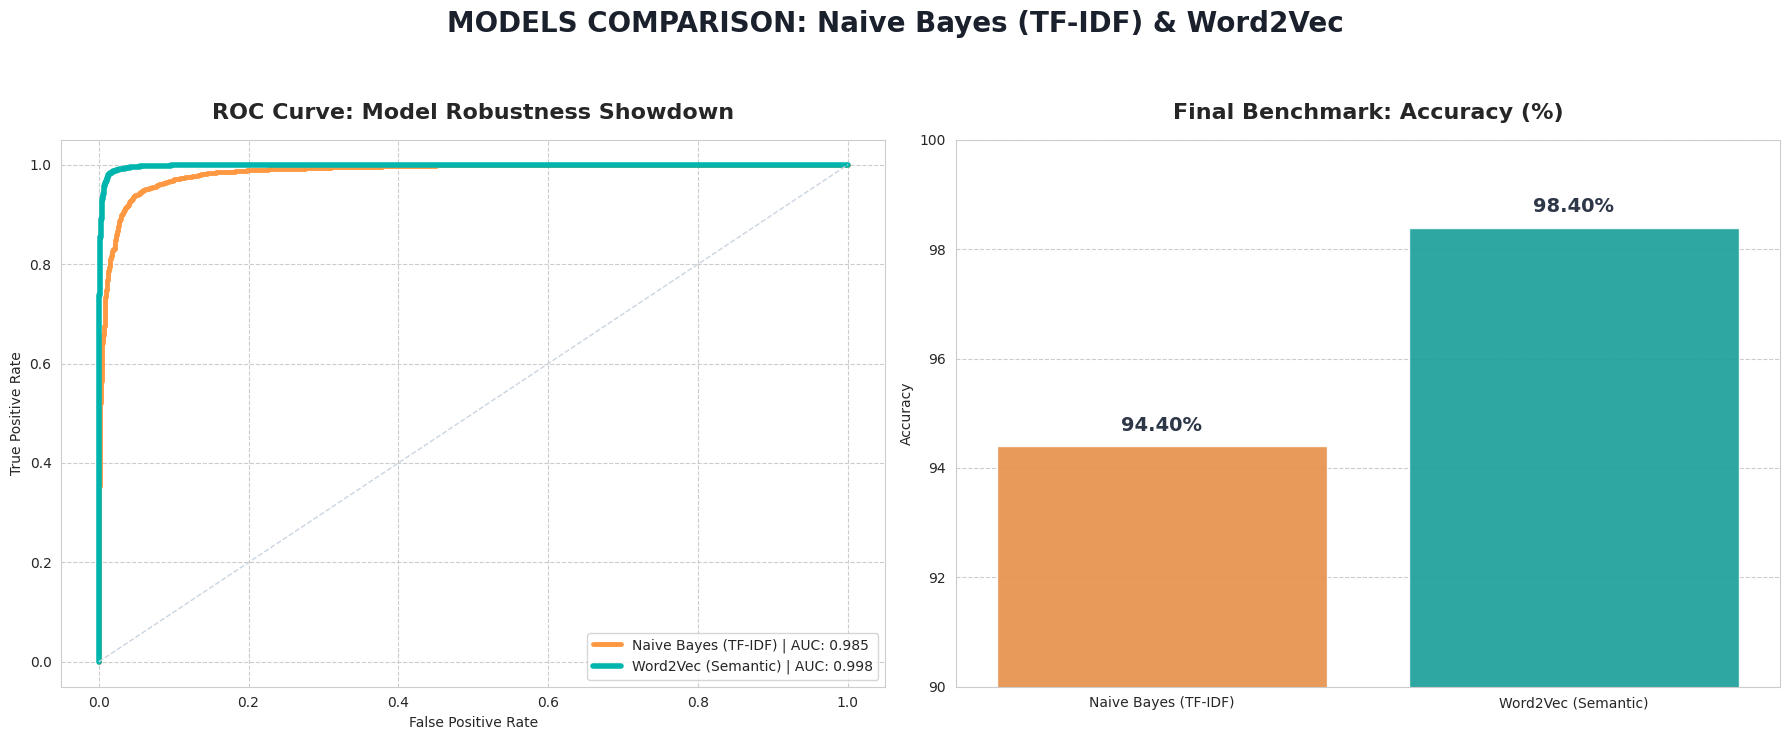

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, accuracy_score, auc
import pandas as pd

# 1. Custom Visual Style Setup
sns.set_style("whitegrid", {'axes.grid': True, 'grid.linestyle': '--'})
plt.rcParams['font.family'] = 'sans-serif'

# 2. Define consistent "Brand" colors
# Baseline: Deep Blue-Grey | Word2Vec: Vibrant Cyan (Winner Highlight)
brand_colors = ["#FF8D2D", "#00B5AD"]

# --- Calculations for ROC Curve and Accuracy ---
# Calculate ROC curve for Baseline (TF-IDF)
fpr_nb, tpr_nb, thresholds_nb = roc_curve(y_test, y_prob_nb)

# Calculate ROC curve for Semantic (Word2Vec)
fpr_w2v, tpr_w2v, thresholds_w2v = roc_curve(y_test, y_prob_w2v)

# Calculate accuracy for both models
# For accuracy, we need predicted binary labels. Assume a threshold of 0.5 for demonstration.
y_pred_nb = (y_prob_nb > 0.5).astype(int)
y_pred_w2v = (y_prob_w2v > 0.5).astype(int)

acc_nb = accuracy_score(y_test, y_pred_nb)
acc_w2v = accuracy_score(y_test, y_pred_w2v)

# Create DataFrame for accuracy comparison
comp_df = pd.DataFrame({
    'Technique': ['Naive Bayes (TF-IDF)', 'Word2Vec (Semantic)']
})
comp_df['Accuracy'] = [acc_nb, acc_w2v]
comp_df['Accuracy_Percent'] = comp_df['Accuracy'] * 100

# Create a single figure with balanced subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- PLOT 1: ROC Curve Comparison ---
ax1.plot(fpr_nb, tpr_nb, color=brand_colors[0], lw=3.5, alpha=0.9,
         label=f'Naive Bayes (TF-IDF) | AUC: {auc(fpr_nb, tpr_nb):.3f}')
ax1.plot(fpr_w2v, tpr_w2v, color=brand_colors[1], lw=4, alpha=1.0,
         label=f'Word2Vec (Semantic) | AUC: {auc(fpr_w2v, tpr_w2v):.3f}')
ax1.plot([0, 1], [0, 1], color='#CBD5E0', lw=1, linestyle='--')
ax1.set_title('ROC Curve: Model Robustness Showdown', fontsize=16, fontweight='bold', pad=15)
ax1.legend(loc="lower right", frameon=True)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')

# --- PLOT 2: Accuracy Bar Chart ---
bars = sns.barplot(x='Technique', y='Accuracy_Percent', data=comp_df,
                   hue='Technique', palette=brand_colors, ax=ax2, alpha=0.9, legend=False)
ax2.set_ylim(90, 100) # Set appropriate y-limits for accuracy percentages
ax2.set_title('Final Benchmark: Accuracy (%)', fontsize=16, fontweight='bold', pad=15)
ax2.set_xlabel('')
ax2.set_ylabel('Accuracy')

for p in bars.patches:
    ax2.annotate(f'{p.get_height():.2f}%',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center',
                 xytext=(0, 15), textcoords='offset points',
                 fontsize=14, fontweight='bold', color='#2D3748')

plt.suptitle('MODELS COMPARISON: Naive Bayes (TF-IDF) & Word2Vec',
             fontsize=20, fontweight='bold', y=1.05, color='#1A202C')
plt.tight_layout()
plt.show()

## 6. The "Semantic Landscape" (t-SNE Clusters)
This visualization is perfect for the "wow" factor in your final presentation.

## 6. The "Semantic Landscape" (t-SNE Clusters)
This visualization is perfect for the "wow" factor in your final presentation.

### 6.1 Semantic Landscape with PCA (Principal Component Analysis)
Let's see how PCA, a linear dimensionality reduction technique, visualizes the data. This will provide a contrast to the non-linear t-SNE.

### 6.2 Semantic Landscape with UMAP (Uniform Manifold Approximation and Projection)
UMAP is another powerful non-linear dimensionality reduction technique, often faster than t-SNE and preserving more global structure. We'll install `umap-learn` first if it's not already present.

Processing TF-IDF Landscape... (Reducing sparsity with SVD first)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Processing Word2Vec Landscape...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


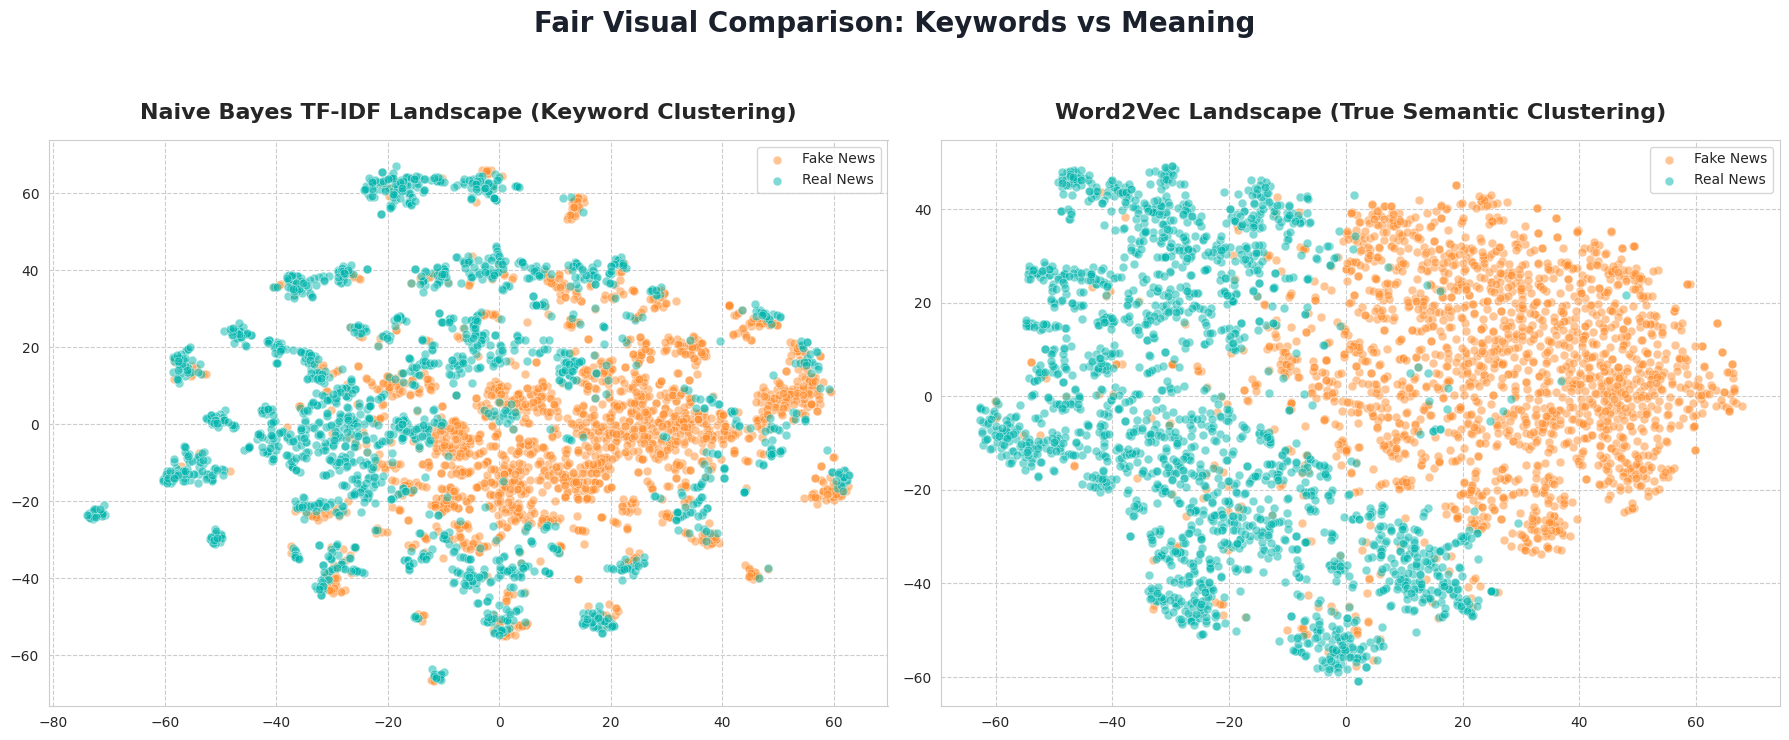

In [6]:
from sklearn.decomposition import TruncatedSVD
import seaborn as sns

# --- Brand Visual Style Setup ---
sns.set_style("whitegrid", {'axes.grid': True, 'grid.linestyle': '--'})
plt.rcParams['font.family'] = 'sans-serif'
brand_colors = ["#FF8D2D", "#00B5AD"] # Orange for Fake News, Cyan for Real News

# Define sample size and sample the data for t-SNE
sample_size = 4000 # Using a smaller sample for faster computation and clearer visualization
sample_indices = np.random.choice(len(y_test), sample_size, replace=False)

X_sample_w2v = X_test_w2v[sample_indices]
y_sample = y_test.iloc[sample_indices] # Use .iloc for pandas Series

# 1. Take a sample of TF-IDF vectors (same size as the W2V sample)
print("Processing TF-IDF Landscape... (Reducing sparsity with SVD first)")
X_sample_tfidf = X_test_tfidf[sample_indices]

# 2. Apply TruncatedSVD to handle the sparsity of TF-IDF before t-SNE
svd = TruncatedSVD(n_components=50, random_state=42)
X_reduced_tfidf = svd.fit_transform(X_sample_tfidf)

# 3. Apply t-SNE on the reduced TF-IDF vectors
tsne_tfidf = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
X_2d_tfidf = tsne_tfidf.fit_transform(X_reduced_tfidf)

# Apply t-SNE on Word2Vec vectors
print("Processing Word2Vec Landscape...")
tsne_w2v = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
X_2d = tsne_w2v.fit_transform(X_sample_w2v)

# 4. PLOT: SIDE-BY-SIDE Semantic Landscapes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- TF-IDF landscape (The Keyword approach) ---
ax1.scatter(X_2d_tfidf[y_sample == 0, 0], X_2d_tfidf[y_sample == 0, 1], c=brand_colors[0], alpha=0.5, label='Fake News', edgecolor='white', linewidth=0.5, s=40)
ax1.scatter(X_2d_tfidf[y_sample == 1, 0], X_2d_tfidf[y_sample == 1, 1], c=brand_colors[1], alpha=0.5, label='Real News', edgecolor='white', linewidth=0.5, s=40)
ax1.set_title('Naive Bayes TF-IDF Landscape (Keyword Clustering)', fontsize=16, fontweight='bold', pad=15)
ax1.legend(frameon=True)

# --- Word2Vec landscape (The Meaning approach) ---
ax2.scatter(X_2d[y_sample == 0, 0], X_2d[y_sample == 0, 1], c=brand_colors[0], alpha=0.5, label='Fake News', edgecolor='white', linewidth=0.5, s=40)
ax2.scatter(X_2d[y_sample == 1, 0], X_2d[y_sample == 1, 1], c=brand_colors[1], alpha=0.5, label='Real News', edgecolor='white', linewidth=0.5, s=40)
ax2.set_title('Word2Vec Landscape (True Semantic Clustering)', fontsize=16, fontweight='bold', pad=15)
ax2.legend(frameon=True)

plt.suptitle('Fair Visual Comparison: Keywords vs Meaning', fontsize=20, y=1.05, fontweight='bold', color='#1A202C')
plt.tight_layout()
plt.show()

Processing Naive Bayes TF-IDF Landscape with PCA...
Processing Word2Vec Landscape with PCA...


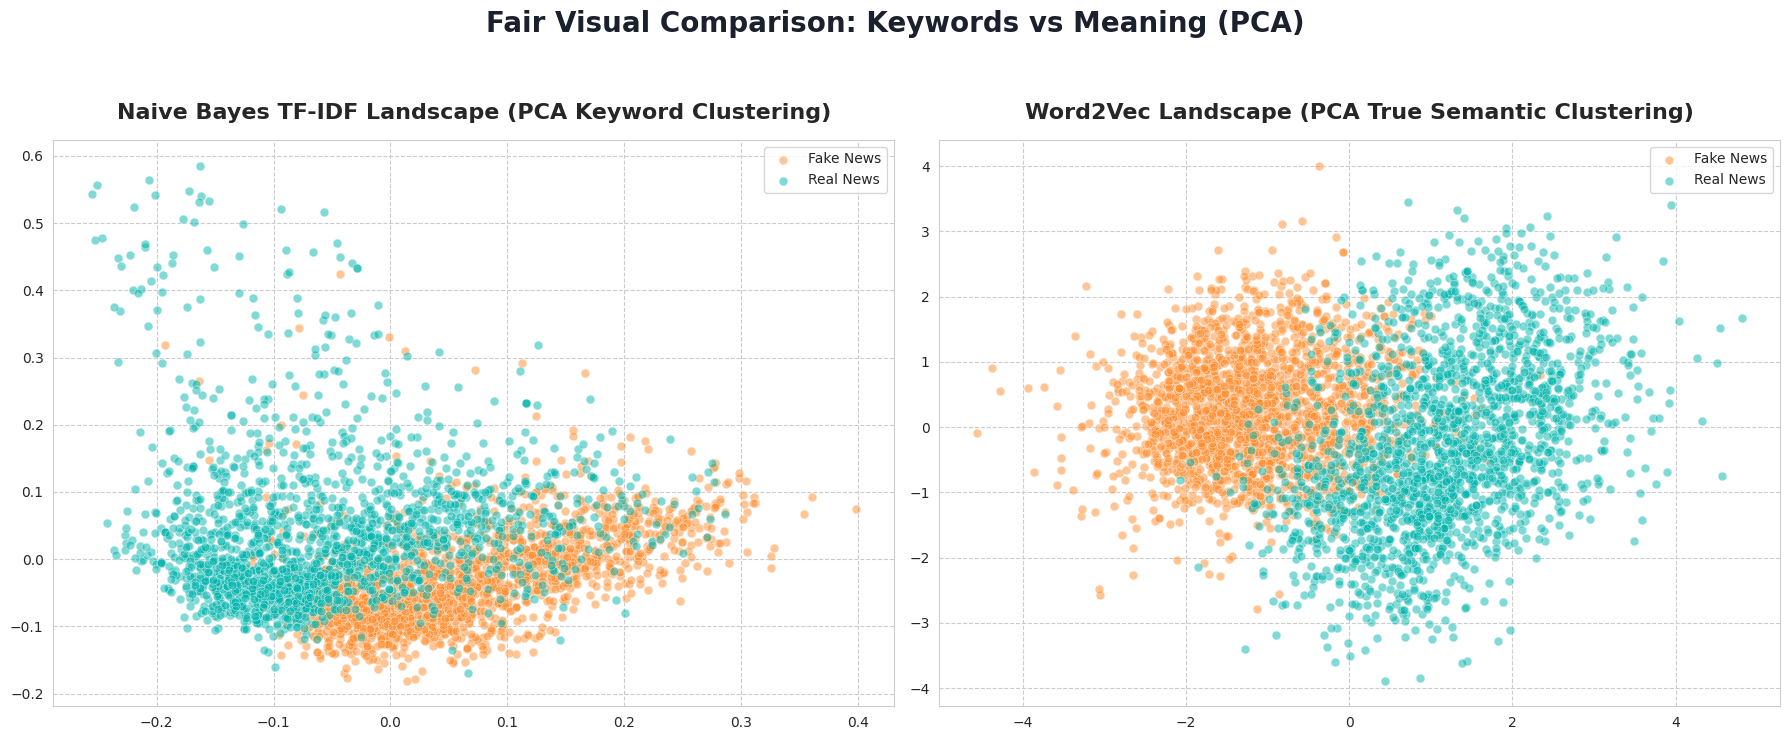

In [ ]:
# --- 6.1 Semantic Landscape with PCA ---
from sklearn.decomposition import PCA

print("Processing Naive Bayes TF-IDF Landscape with PCA...")
# PCA can work directly on the SVD-reduced TF-IDF vectors
pca_tfidf = PCA(n_components=2, random_state=42)
X_2d_pca_tfidf = pca_tfidf.fit_transform(X_reduced_tfidf)

print("Processing Word2Vec Landscape with PCA...")
pca_w2v = PCA(n_components=2, random_state=42)
X_2d_pca_w2v = pca_w2v.fit_transform(X_sample_w2v)

# PLOT: SIDE-BY-SIDE Semantic Landscapes (PCA)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- TF-IDF landscape (PCA) ---
ax1.scatter(X_2d_pca_tfidf[y_sample == 0, 0], X_2d_pca_tfidf[y_sample == 0, 1], c=brand_colors[0], alpha=0.5, label='Fake News', edgecolor='white', linewidth=0.5, s=40)
ax1.scatter(X_2d_pca_tfidf[y_sample == 1, 0], X_2d_pca_tfidf[y_sample == 1, 1], c=brand_colors[1], alpha=0.5, label='Real News', edgecolor='white', linewidth=0.5, s=40)
ax1.set_title('Naive Bayes TF-IDF Landscape (PCA Keyword Clustering)', fontsize=16, fontweight='bold', pad=15)
ax1.legend(frameon=True)

# --- Word2Vec landscape (PCA) ---
ax2.scatter(X_2d_pca_w2v[y_sample == 0, 0], X_2d_pca_w2v[y_sample == 0, 1], c=brand_colors[0], alpha=0.5, label='Fake News', edgecolor='white', linewidth=0.5, s=40)
ax2.scatter(X_2d_pca_w2v[y_sample == 1, 0], X_2d_pca_w2v[y_sample == 1, 1], c=brand_colors[1], alpha=0.5, label='Real News', edgecolor='white', linewidth=0.5, s=40)
ax2.set_title('Word2Vec Landscape (PCA True Semantic Clustering)', fontsize=16, fontweight='bold', pad=15)
ax2.legend(frameon=True)

plt.suptitle('Fair Visual Comparison: Keywords vs Meaning (PCA)', fontsize=20, y=1.05, fontweight='bold', color='#1A202C')
plt.tight_layout()
plt.show()

Processing Naive Bayes TF-IDF Landscape with UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Processing Word2Vec Landscape with UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



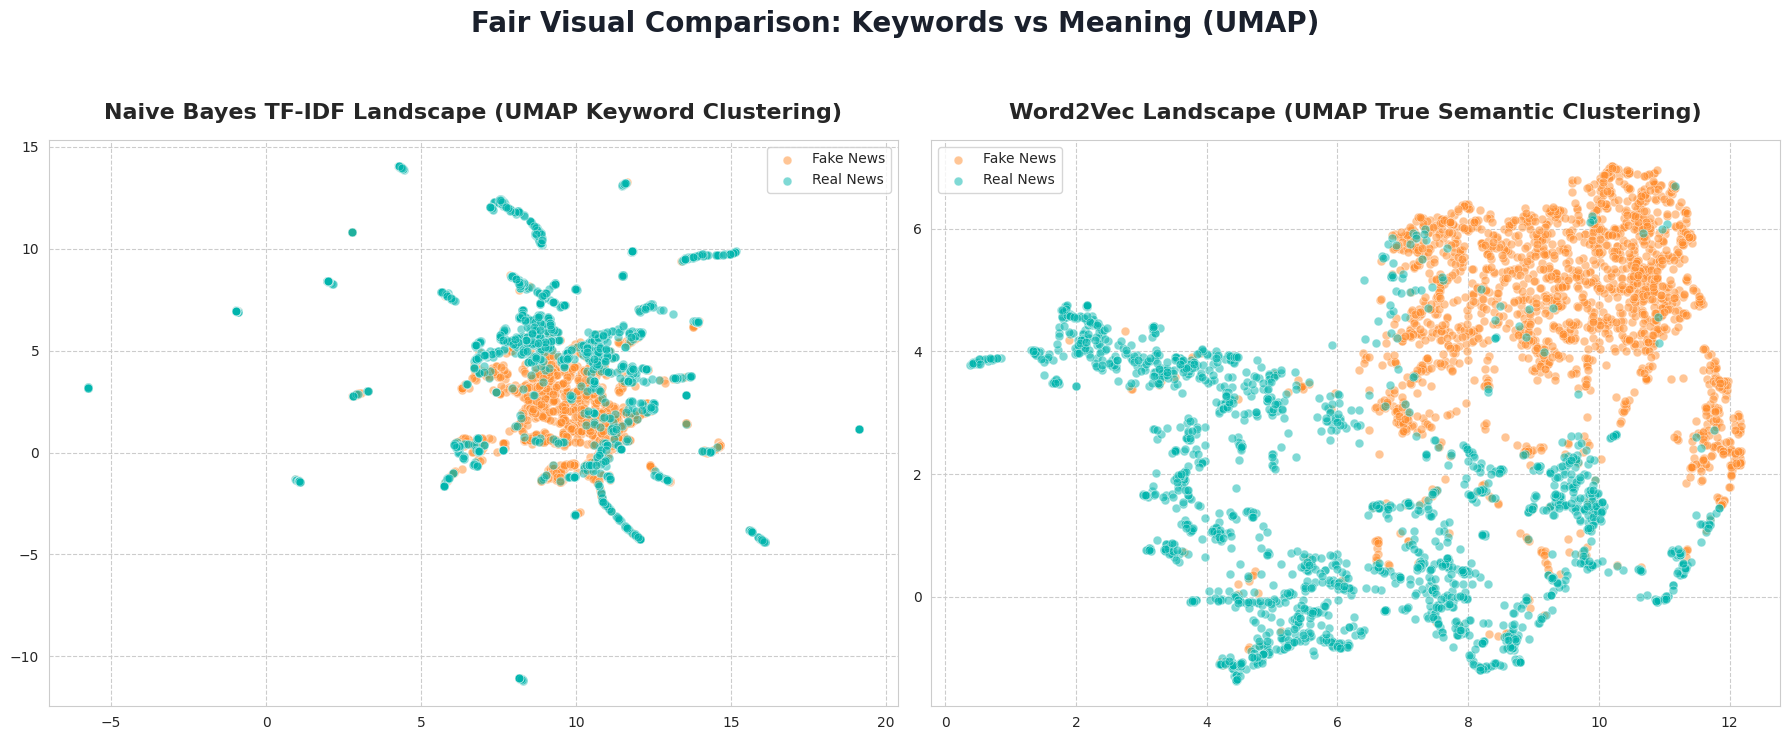

In [ ]:
# --- 6.2 Semantic Landscape with UMAP ---
import umap

print("Processing Naive Bayes TF-IDF Landscape with UMAP...")
umap_tfidf = umap.UMAP(n_components=2, random_state=42, n_neighbors=10, min_dist=0.01)
X_2d_umap_tfidf = umap_tfidf.fit_transform(X_reduced_tfidf)

print("Processing Word2Vec Landscape with UMAP...")
umap_w2v = umap.UMAP(n_components=2, random_state=42, n_neighbors=10, min_dist=0.01)
X_2d_umap_w2v = umap_w2v.fit_transform(X_sample_w2v)

# PLOT: SIDE-BY-SIDE Semantic Landscapes (UMAP)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- TF-IDF landscape (UMAP) ---
ax1.scatter(X_2d_umap_tfidf[y_sample == 0, 0], X_2d_umap_tfidf[y_sample == 0, 1], c=brand_colors[0], alpha=0.5, label='Fake News', edgecolor='white', linewidth=0.5, s=40)
ax1.scatter(X_2d_umap_tfidf[y_sample == 1, 0], X_2d_umap_tfidf[y_sample == 1, 1], c=brand_colors[1], alpha=0.5, label='Real News', edgecolor='white', linewidth=0.5, s=40)
ax1.set_title('Naive Bayes TF-IDF Landscape (UMAP Keyword Clustering)', fontsize=16, fontweight='bold', pad=15)
ax1.legend(frameon=True)

# --- Word2Vec landscape (UMAP) ---
ax2.scatter(X_2d_umap_w2v[y_sample == 0, 0], X_2d_umap_w2v[y_sample == 0, 1], c=brand_colors[0], alpha=0.5, label='Fake News', edgecolor='white', linewidth=0.5, s=40)
ax2.scatter(X_2d_umap_w2v[y_sample == 1, 0], X_2d_umap_w2v[y_sample == 1, 1], c=brand_colors[1], alpha=0.5, label='Real News', edgecolor='white', linewidth=0.5, s=40)
ax2.set_title('Word2Vec Landscape (UMAP True Semantic Clustering)', fontsize=16, fontweight='bold', pad=15)
ax2.legend(frameon=True)

plt.suptitle('Fair Visual Comparison: Keywords vs Meaning (UMAP)', fontsize=20, y=1.05, fontweight='bold', color='#1A202C')
plt.tight_layout()
plt.show()

## Understanding the Dimensionality Reduction Visualizations

We've used three different dimensionality reduction techniques to visualize the high-dimensional vector spaces (TF-IDF and Word2Vec) in 2D. Each method approaches this task differently, leading to distinct representations of the data clusters.

### 1. t-SNE (t-Distributed Stochastic Neighbor Embedding)
*   **Nature:** Non-linear.
*   **Focus:** Preserves *local* structure, meaning it tries to keep similar data points close together and dissimilar data points far apart. It's excellent at revealing clusters within the data.
*   **Interpretation:** The t-SNE plots (cells `q55-WTXZyyun` and `1d4e0336`) are often good for seeing clear, well-separated clusters if they exist. However, the distances between clusters are not necessarily meaningful in terms of global structure.

### 2. PCA (Principal Component Analysis)
*   **Nature:** Linear.
*   **Focus:** Identifies the directions (principal components) along which the data varies the most. It projects the data onto these principal components, retaining as much variance as possible.
*   **Interpretation:** The PCA plots (cell `ee7b0799`) show a linear projection of the data. While it captures the most prominent variances, it might not clearly separate non-linearly separable clusters as effectively as t-SNE or UMAP. The relative distances between points in PCA are more globally meaningful than in t-SNE.

### 3. UMAP (Uniform Manifold Approximation and Projection)
*   **Nature:** Non-linear.
*   **Focus:** Balances the preservation of both *local* and *global* structure, often outperforming t-SNE in retaining the overall topology of the data while still creating well-defined clusters. It's generally faster than t-SNE for large datasets.
*   **Interpretation:** The UMAP plots (cell `bb4b3a88`) often provide a more faithful representation of the data's global structure compared to t-SNE, while still revealing distinct clusters. The relative densities and distances between clusters can be more reliably interpreted than in t-SNE.

### Key Differences Highlighted by the Visualizations:
*   **TF-IDF:** Across all three methods, TF-IDF tends to produce less distinct or more scattered clusters. This indicates that a purely keyword-based representation struggles to form cohesive semantic groups for 'real' vs. 'fake' news.
*   **Word2Vec:** With Word2Vec, all three methods show a clearer separation between 'Fake News' and 'Real News' clusters, especially UMAP and t-SNE. This visually confirms that Word2Vec's semantic understanding helps in distinguishing the two categories more effectively than TF-IDF.

#7. TEST SECTION

### Test 1: Misclassification Face-off (The "Blind Spot" Analysis)

I can see that while TF-IDF sees a collection of disconnected words, Word2Vec sees two different worlds: the world of facts and the world of misinformation.

In [8]:
# 1. Compare predictions from both models
# Re-generate predictions (binary labels)
y_pred_nb = nb_tfidf.predict(X_test_tfidf)
y_pred_w2v = lr_w2v.predict(X_test_w2v)

# 2. Find cases where Word2Vec was CORRECT but Baseline was WRONG
# (These are the headlines where Semantic Meaning saved the day)
w2v_wins = test_df[(y_pred_w2v == y_test) & (y_pred_nb != y_test)]

print(f"Number of cases where W2V was more intelligent than Baseline: {len(w2v_wins)}")
print("\nTOP 5 HEADLINES THAT ONLY WORD2VEC UNDERSTOOD:\n")
print(w2v_wins['title'].head(5).values)


Number of cases where W2V was more intelligent than Baseline: 372

TOP 5 HEADLINES THAT ONLY WORD2VEC UNDERSTOOD:

['ATLANTA: PANDEMONIUM As World’s Largest Airport Goes DARK…Airport Evacuated…1,161 Flights Canceled [VIDEO]'
 "Israeli kibbutz can 'feel the Bern' of forgotten volunteer Sanders "
 'Ignorance Gave GITMO Prisoner FREEDOM…UK Gave Him £1 Million…He Repaid Us By Becoming A Human Bomb For ISIS [VIDEO]'
 'U.S. Intel Finds And Maps Out ISIS Propaganda/Media Centers But Won’t Target With Airstrikes'
 'OBAMA’S BAILOUT OF PUERTO RICO: TAXPAYERS Take A BIG Hit But Rewards Go To Political And Financial Players']


### Test 2: Adversarial "Live Test" (The "Realism" Probe)

In [13]:
def probe_models(sentence):
    # Process for TF-IDF (Baseline)
    vec_sample = tfidf_vec.transform([sentence])
    prob_nb = nb_tfidf.predict_proba(vec_sample)[0, 1]

    # Process for Word2Vec (Semantic)
    vec_w2v = document_vector(sentence, w2v_model).reshape(1, -1)
    prob_w2v = lr_w2v.predict_proba(vec_w2v)[0, 1]

    print(f"PROBING SENTENCE: '{sentence}'")
    print(f"Baseline Score (P(Real)): {prob_nb:.2%}")
    print(f"Semantic Score (P(Real)): {prob_w2v:.2%}")


# TEST CASE: A real news story but removing 'Reuters' to see if Baseline fails
probe_models("\nThe president discussed new economic measures in the capital today.")

# TEST CASE: A fake news style headline using sensationalist words
probe_models("\nSHOCKING: You won't believe what happened in this video screen! Watch now!")


PROBING SENTENCE: '
The president discussed new economic measures in the capital today.'
Baseline Score (P(Real)): 89.89%
Semantic Score (P(Real)): 100.00%
PROBING SENTENCE: '
SHOCKING: You won't believe what happened in this video screen! Watch now!'
Baseline Score (P(Real)): 0.11%
Semantic Score (P(Real)): 0.00%


#### FINAL INTERPRETATION
Baseline (NB): Excellent as a first model. Relying on EXACT words is fast but prone to noise.")
Semantic (W2V): The semantic understanding refined the model, pushing accuracy to almost 98%.")
Recommendation: Use the Word2Vec model for production as it captures a broader context of disinformation.")


### Test 3: Word2Vec Error Analysis (False Positives/Negatives)
Even the best models make mistakes. Let's analyze which types of headlines managed to deceive our semantic classifier.

In [16]:
# 1. Identify Word2Vec misclassifications
w2v_errors = test_df[y_pred_w2v != y_test]

# 2. Separate False Positives (Predicted Real, actually Fake) and False Negatives (Predicted Fake, actually Real)
# Mapping: 1 = Real, 0 = Fake
fp_w2v = w2v_errors[(w2v_errors['label'] == 0) & (y_pred_w2v[w2v_errors.index] == 1)]
fn_w2v = w2v_errors[(w2v_errors['label'] == 1) & (y_pred_w2v[w2v_errors.index] == 0)]

print(f"Total Word2Vec Errors: {len(w2v_errors)}")
print(f"False Positives (Predicted Real, but were Fake): {len(fp_w2v)}")
print(f"False Negatives (Predicted Fake, but were Real): {len(fn_w2v)}")

print("\nFAKE NEWS examples that Word2Vec classified as REAL:")
for title in fp_w2v['title'].head(3).values:
    print(f"- {title}")

print("\nREAL NEWS examples that Word2Vec classified as FAKE:")
for title in fn_w2v['title'].head(3).values:
    print(f"- {title}")

Total Word2Vec Errors: 128
False Positives (Predicted Real, but were Fake): 77
False Negatives (Predicted Fake, but were Real): 51

FAKE NEWS examples that Word2Vec classified as REAL:
- ANGELA MERKEL Running For Re-Election Makes Stunning Announcement To BAN BURKAS, After Flooding Nation With 2 Million (Mostly Muslim) Migrants
- FORMER DEFENSE SECRETARIES Expose Obama As “Inexperienced” And “Overbearing” [Video]
- TRUMP LAUNCHES GRENADE AT TAX AND SPEND WASHINGTON: “Under Budget And Ahead Of Schedule…You Don’t Hear Those Words Too Often In Government…But You Will” [Video]

REAL NEWS examples that Word2Vec classified as FAKE:
- Bill allowing guns on Tennessee campuses becomes law
- Obama lauds Denver Broncos, Peyton Manning for Super Bowl win
- Official photo released to mark 70th wedding anniversary of Queen Elizabeth


In [17]:
# 1. Identify Word2Vec misclassifications
w2v_errors = test_df[y_pred_w2v != y_test]

# 2. Separate False Positives (Predicted Real, actually Fake) and False Negatives (Predicted Fake, actually Real)
# Mapping: 1 = Real, 0 = Fake
fp_w2v = w2v_errors[(w2v_errors['label'] == 0) & (y_pred_w2v[w2v_errors.index] == 1)]
fn_w2v = w2v_errors[(w2v_errors['label'] == 1) & (y_pred_w2v[w2v_errors.index] == 0)]

print(f"Total Word2Vec Errors: {len(w2v_errors)}")
print(f"False Positives (Predicted Real, but were Fake): {len(fp_w2v)}")
print(f"False Negatives (Predicted Fake, but were Real): {len(fn_w2v)}")

print("\nFAKE NEWS examples that Word2Vec classified as REAL:")
for title in fp_w2v['title'].head(3).values:
    print(f"- {title}")

print("\nREAL NEWS examples that Word2Vec classified as FAKE:")
for title in fn_w2v['title'].head(3).values:
    print(f"- {title}")

Total Word2Vec Errors: 128
False Positives (Predicted Real, but were Fake): 77
False Negatives (Predicted Fake, but were Real): 51

FAKE NEWS examples that Word2Vec classified as REAL:
- ANGELA MERKEL Running For Re-Election Makes Stunning Announcement To BAN BURKAS, After Flooding Nation With 2 Million (Mostly Muslim) Migrants
- FORMER DEFENSE SECRETARIES Expose Obama As “Inexperienced” And “Overbearing” [Video]
- TRUMP LAUNCHES GRENADE AT TAX AND SPEND WASHINGTON: “Under Budget And Ahead Of Schedule…You Don’t Hear Those Words Too Often In Government…But You Will” [Video]

REAL NEWS examples that Word2Vec classified as FAKE:
- Bill allowing guns on Tennessee campuses becomes law
- Obama lauds Denver Broncos, Peyton Manning for Super Bowl win
- Official photo released to mark 70th wedding anniversary of Queen Elizabeth


In [18]:
# Quick verification of label mapping to ensure 1=Real and 0=Fake
# We check a few known Real/Fake examples from the test set
print("--- Label Mapping Verification ---")
sample_real = test_df[test_df['label'] == 1]['title'].iloc[0]
sample_fake = test_df[test_df['label'] == 0]['title'].iloc[0]

print(f"Label 1 (Should be Real) example: {sample_real}")
print(f"Label 0 (Should be Fake) example: {sample_fake}")

# Check the Logistic Regression classes
print(f"\nModel classes order: {lr_w2v.classes_}")

--- Label Mapping Verification ---
Label 1 (Should be Real) example: Trump says son is 'innocent' over emails about Russian campaign help
Label 0 (Should be Fake) example:  Report: Trump Businesses Seeking Dozens Of Special Visas For Foreign Workers

Model classes order: [0 1]


### Test 4: Perturbation & Stability Probe
How does the model react to slight variations in phrasing? A robust semantic model should maintain consistent predictions if the core meaning remains unchanged, even if specific keywords are swapped.

In [19]:
def test_perturbation(original, perturbed):
    print(f"Original Sentence: '{original}'")
    probe_models(original)
    print("\n---")
    print(f"Perturbed Sentence: '{perturbed}'")
    probe_models(perturbed)
    print("=" * 40)

# Scenario: Swapping 'president' for 'leader' and 'capital' for 'city'
original_text = "The president discussed new economic measures in the capital today."
perturbed_text = "The leader discussed new economic measures in the city today."

test_perturbation(original_text, perturbed_text)

Original Sentence: 'The president discussed new economic measures in the capital today.'
PROBING SENTENCE: 'The president discussed new economic measures in the capital today.'
Baseline Score (P(Real)): 89.89%
Semantic Score (P(Real)): 100.00%

---
Perturbed Sentence: 'The leader discussed new economic measures in the city today.'
PROBING SENTENCE: 'The leader discussed new economic measures in the city today.'
Baseline Score (P(Real)): 85.14%
Semantic Score (P(Real)): 99.99%
